In [30]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:

df = pd.read_excel("glass.xlsx")

df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [32]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [33]:

print(df.isnull().sum())

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64


In [34]:

print(df.duplicated().sum())

1


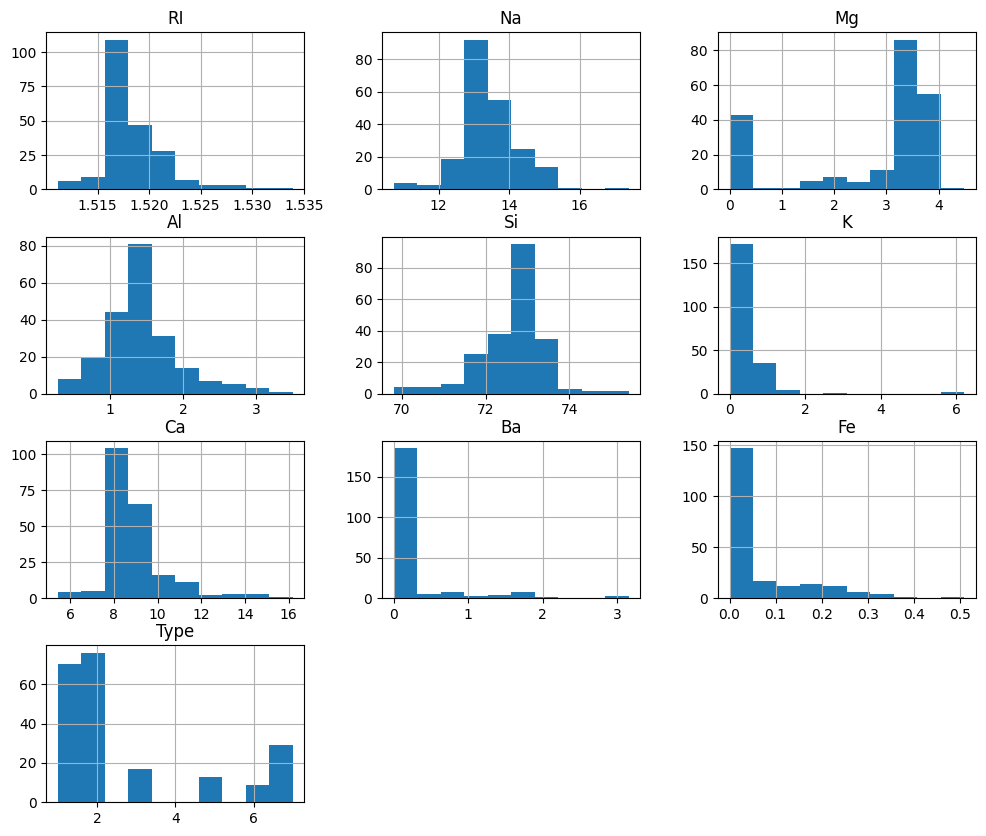

In [35]:
# Histograms

df.hist(figsize=(12,10))

plt.show()

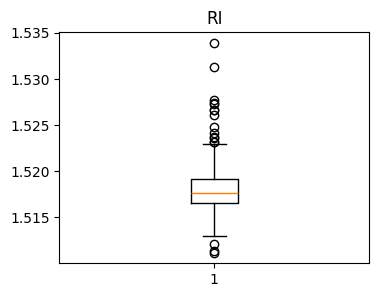

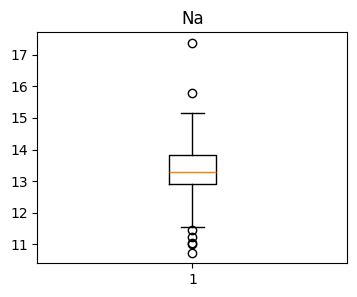

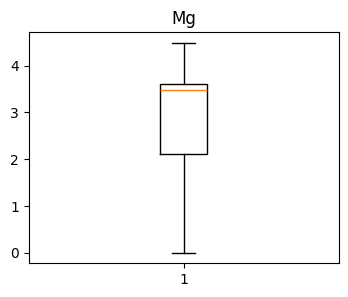

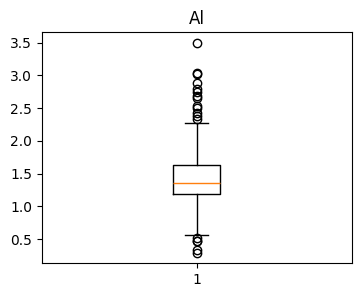

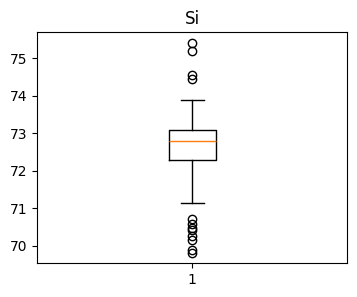

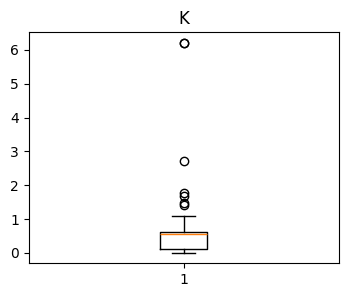

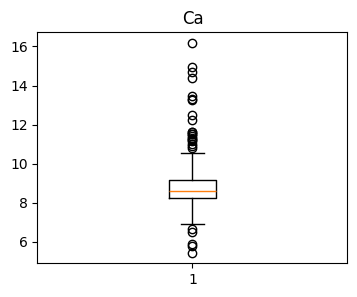

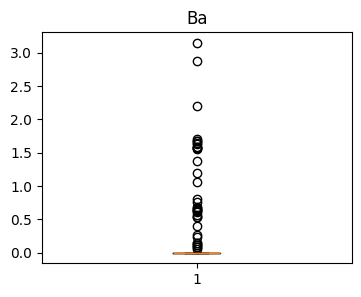

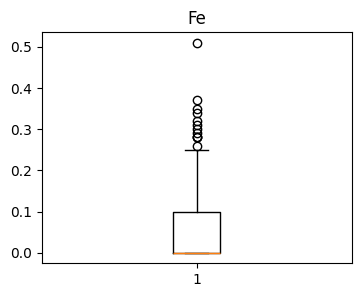

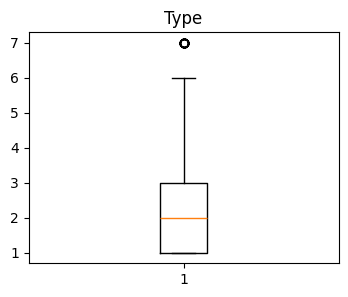

In [36]:
# Boxplots

for col in df.columns:

    plt.figure(figsize=(4,3))

    plt.boxplot(df[col])

    plt.title(col)

    plt.show()

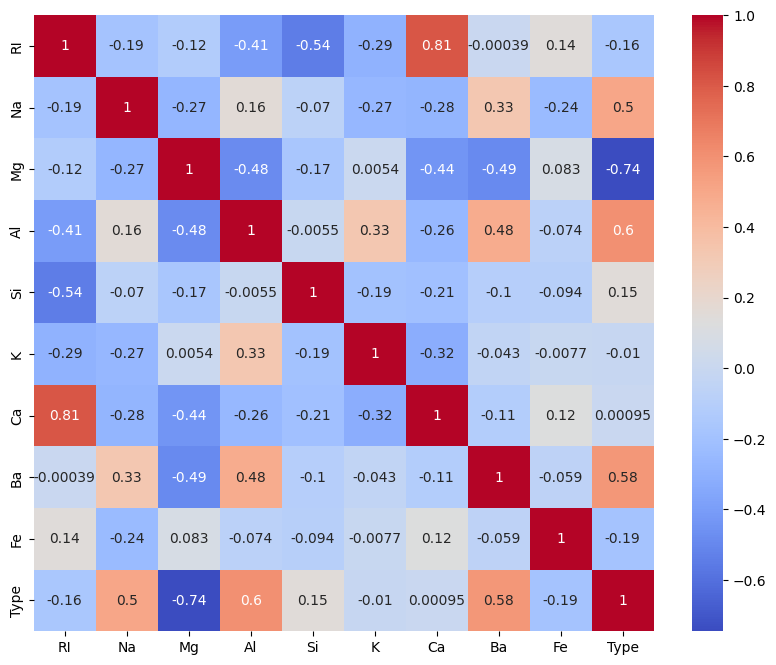

In [37]:
# Correlation matrix

plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

In [38]:
print(df.isnull().sum())
print(df.duplicated().sum())
print(df["Type"].value_counts())

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64
1
Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64


In [39]:
# Removing duplicate rows

df = df.drop_duplicates()

print(df.duplicated().sum())

0


In [40]:
# Features and target

X = df.drop("Type", axis=1)

y = df["Type"]

In [41]:
# Feature scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [42]:
# Train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [43]:
# Random Forest model

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [44]:
# Predictions

y_pred = rf.predict(X_test)

In [45]:
# Accuracy

from sklearn.metrics import accuracy_score

print("Accuracy :",
      accuracy_score(y_test, y_pred))

Accuracy : 0.7674418604651163


In [46]:
# Precision, Recall, F1

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Precision :",
      precision_score(y_test,y_pred,average="weighted"))

print("Recall :",
      recall_score(y_test,y_pred, average="weighted"))

print("F1 Score :",
      f1_score(y_test,y_pred,average="weighted"))

Precision : 0.7823920265780729
Recall : 0.7674418604651163
F1 Score : 0.7628818969448244


In [47]:
# Classification report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.71      1.00      0.83        10
           2       0.67      0.67      0.67        15
           3       1.00      0.67      0.80         3
           5       0.50      0.33      0.40         3
           6       1.00      0.67      0.80         3
           7       1.00      0.89      0.94         9

    accuracy                           0.77        43
   macro avg       0.81      0.70      0.74        43
weighted avg       0.78      0.77      0.76        43



In [48]:

# Bagging

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)

bagging.fit(X_train, y_train)

bag_pred = bagging.predict(X_test)

print("Bagging Accuracy :",
      accuracy_score(y_test, bag_pred))

Bagging Accuracy : 0.813953488372093


In [49]:
# Boosting

from sklearn.ensemble import AdaBoostClassifier

boosting = AdaBoostClassifier(
    n_estimators=50,
    random_state=42
)

boosting.fit(X_train, y_train)

boost_pred = boosting.predict(X_test)

print("Boosting Accuracy :",
      accuracy_score(y_test, boost_pred))

Boosting Accuracy : 0.6046511627906976


In [50]:
# Comparing models

print("Random Forest Accuracy :",
      accuracy_score(y_test, y_pred))

print("Bagging Accuracy :",
      accuracy_score(y_test, bag_pred))

print("Boosting Accuracy :",
      accuracy_score(y_test, boost_pred))

Random Forest Accuracy : 0.7674418604651163
Bagging Accuracy : 0.813953488372093
Boosting Accuracy : 0.6046511627906976


Analysis of Patterns and Correlations

The histograms and boxplots were used to understand the distribution of features and identify outliers.

The correlation matrix showed relationships among the numerical features.

Some features exhibited stronger correlations than others, indicating their potential importance in glass classification.

Missing Value Handling

The dataset did not contain any missing values.

Therefore, no imputation or removal techniques were required.

Bagging and Boosting Methods


Bagging trains multiple models independently and combines their predictions.

Boosting trains models sequentially, where each new model focuses on correcting the errors of previous models.

Bagging primarily reduces variance, while Boosting primarily reduces bias.

Handling Imbalanced Data


Imbalanced data can be handled using techniques such as oversampling, undersampling, or class weighting.

These methods help ensure that minority classes receive adequate representation during model training.

Comparison of Models

Random Forest Accuracy = 0.7674

Bagging Accuracy = 0.8140

Boosting Accuracy = 0.6047

Among the three models, Bagging achieved the highest accuracy on the test dataset. Random Forest also performed well, while Boosting showed comparatively lower accuracy.